# Distributions

This experiment try to stress the behavior of the sorting algorithm based on the keys distribution.\
Three types of distribution are tested:

1. uniform
2. few-unique
3. skewed

Here is reported the common configuration for all the experiments:

* **n_keys** : $10^9$
* **n_ranks** : $16$
* **n_threads** : $4$
* **merging_strategy** : binary
* **sorting_algorithm** : radix

Experiments were executed on [**Orfeo, partition GENOA**](https://orfeo-doc.areasciencepark.it/HPC/computational-resources/).

The key metrics here are **time_communication_seconds** and **total_time_seconds**.

In [17]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [18]:
results = pd.read_csv("../Parallel/results/distributions.csv")
results = results[
    ["n_ranks", "distribution", "time_communication_seconds", "time_total_seconds"]
]
results.head()

,n_ranks,distribution,time_communication_seconds,time_total_seconds
0,16,uniform,0.369443,3.998779
1,16,skewed,0.660825,4.037580
2,16,few-unique,0.573044,3.247684
3,16,uniform,0.455500,4.036865
4,16,skewed,0.653498,4.018667


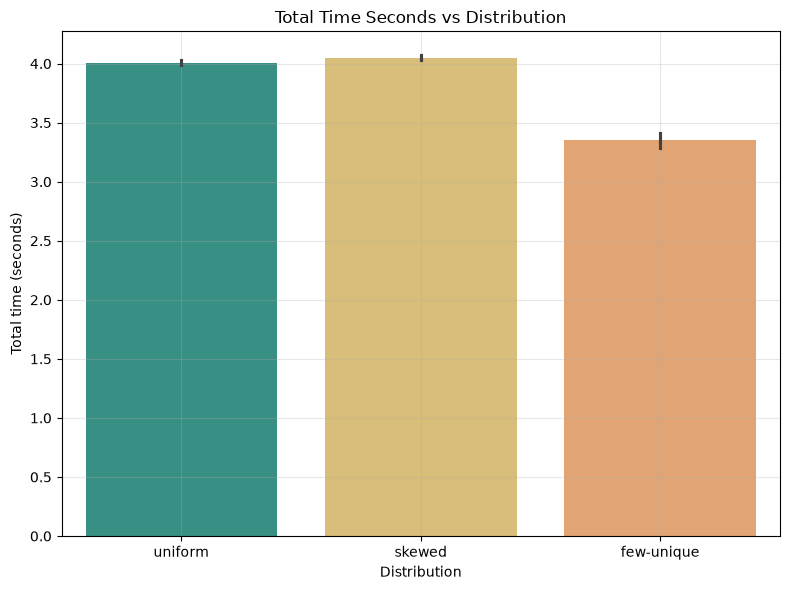

In [19]:
custom_palette = {
    "uniform": "#2a9d8f",
    "skewed": "#e9c46a",
    "few-unique": "#f4a261"
}


plt.figure(figsize=(8, 6))

sns.barplot(
    data=results,
    x="distribution",
    y="time_total_seconds",
    hue="distribution",
    palette=custom_palette,
    legend=False
)

plt.xlabel("Distribution")
plt.ylabel("Total time (seconds)")
plt.title(f"Total Time Seconds vs Distribution")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

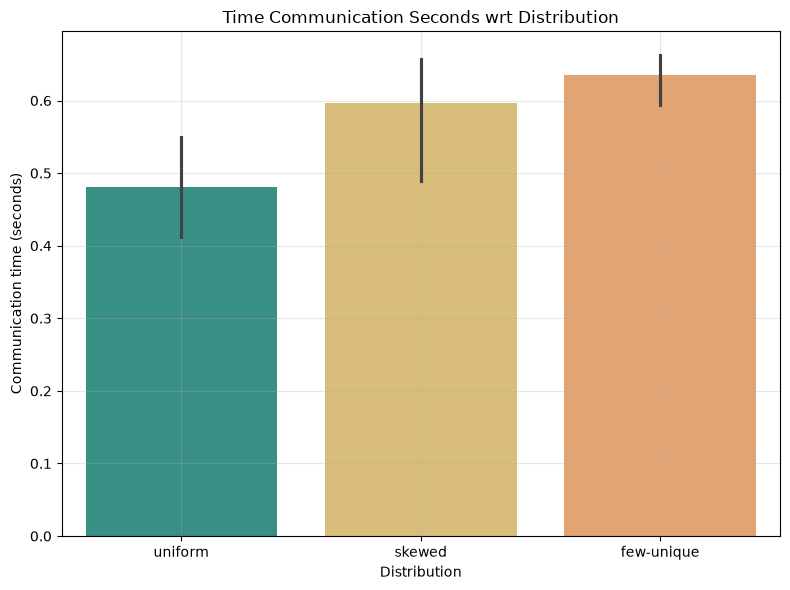

In [20]:

plt.figure(figsize=(8, 6))

sns.barplot(
    data=results,
    x="distribution",
    y="time_communication_seconds",
    hue="distribution",
    palette=custom_palette,
    legend=False
)

plt.xlabel("Distribution")
plt.ylabel("Communication time (seconds)")
plt.title(f"Time Communication Seconds wrt Distribution")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()